# PREPARANDO E PROCESSANDO OS DADOS

In [834]:
import pandas as pd

In [835]:
df = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Analisando e Prevendo Series Temporais\\bicicletas.csv")

In [836]:
df.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [837]:
# checando a dimensão desse conjunto de dados]
# 17429 linhas e 10 colunas
df.shape

(17429, 10)

In [838]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17429 entries, 0 to 17428
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17429 non-null  object 
 1   contagem          17429 non-null  int64  
 2   temperatura       17406 non-null  float64
 3   sensacao_termica  17406 non-null  float64
 4   umidade           17429 non-null  float64
 5   velocidade_vento  17429 non-null  float64
 6   clima             17429 non-null  object 
 7   feriado           17429 non-null  object 
 8   fim_de_semana     17429 non-null  object 
 9   estacao           17429 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.3+ MB


In [839]:
# Analisando e Explorando os Dados:

# Em Non-Null Count podemos conferir a informação de não-nulas de cada uma das colunas. 
# Não temos dados nulos na maioria, pois existem 17429 dados na maioria deles. Mas, nas colunas temperatura e sensacao_termica, temos apenas 17406.
# Outra informação importante é que a coluna data_hora é do tipo objeto, já a coluna de contagem é do tipo inteiro. 
# As outras colunas numéricas são do tipo float (ponto flutuante), que é quando temos um ponto com a casa decimal. Por fim, as colunas categóricas também são do tipo objeto. 

# Tratando dados nulos

In [840]:
#Em relação aos nulos, analisando e somando quantos nulos temos usando a função isnull(). Ela indica se tem nulo ou não, colocando um True (verdadeiro) ou False (falso) e acrescentar .sum().

In [841]:
df.isnull().sum()

data_hora            0
contagem             0
temperatura         23
sensacao_termica    23
umidade              0
velocidade_vento     0
clima                0
feriado              0
fim_de_semana        0
estacao              0
dtype: int64

In [842]:
# Temos zero dados nulos na maioria das colunas, como já havíamos inferido. Mas, temos 23 dados nulos tanto na temperatura quanto na sensacao_termica.

In [843]:
# Foi utilizado o método interpolate() para interpolar valores.
# Vamos exemplificar com o nulo da segunda linha de temperatura. 
# Existem valores não-nulos entre esse dado nulo. Antes dele, temos o número 3.0 e, depois dele, 2.5. 
# Com esse metodo foi tirado uma média desses 2 valores para substituir pelo valor nulo.

In [844]:
df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacao_termica'] = df['sensacao_termica'].interpolate(method='linear')

In [845]:
df.head(10)

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno
5,2015-01-04 05:00:00,46,2.00,2.00,93.0,4.0,Céu limpo,Não,Sim,Inverno
6,2015-01-04 06:00:00,51,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
7,2015-01-04 07:00:00,75,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
8,2015-01-04 08:00:00,131,1.50,-1.00,96.5,8.0,Parcialmente nublado,Não,Sim,Inverno
9,2015-01-04 09:00:00,301,2.00,-0.50,100.0,9.0,Nublado,Não,Sim,Inverno


In [846]:
#Apos a trativa não tem mais dados nulos no resultado.

# Identificando e removendo dados duplicados

In [847]:
# Temos 15 linhas que estão repetidas

In [848]:
df.duplicated().sum()

np.int64(15)

In [849]:
df.duplicated(keep=False) #Usado o parâmetro keep=False. ou seja "false" vai manter os dados duplicados 

0        False
1        False
2        False
3        False
4        False
         ...  
17424     True
17425     True
17426     True
17427     True
17428     True
Length: 17429, dtype: bool

In [850]:
 # armazenando o resultado dos nao duplicadps em uma variável chamada duplicatas. 
 # filtrar somente as linhas duplicadas. Vamos criar uma variável linhas_duplicadas
duplicatas = df.duplicated(keep=False)
linhas_duplicadas = df[duplicatas]
linhas_duplicadas

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
5360,2015-08-15 23:00:00,759,17.0,17.0,59.0,6.0,Céu limpo,Não,Sim,Verão
8174,2015-12-12 11:00:00,1100,12.0,12.0,82.0,20.0,Chuva leve,Não,Sim,Inverno
8175,2015-12-12 12:00:00,1308,13.0,13.0,77.0,26.0,Chuva leve,Não,Sim,Inverno
8528,2015-12-27 05:00:00,57,15.0,15.0,72.0,31.0,Parcialmente nublado,Não,Sim,Inverno
9428,2016-02-02 17:00:00,2846,8.0,4.5,59.5,23.0,Parcialmente nublado,Não,Não,Inverno


In [851]:
# Como ainda não foi possivel visualizar corretamente essa duplicação. Foi Aplicado a funçao de ordenar essas linhas duplicadas pela data_hora para ter uma visualização mais clara.
linhas_duplicadas.sort_values(by='data_hora')

# Por Exemplo data 2015-01-25 existem 2 linhas duplicadas ; data 2015-02-09 existem 2 linhas duplicadas, etc.

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
17422,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
17417,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
17425,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
17421,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
17418,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão


# Removendo dados duplicados

In [852]:
df_limpo = df.drop_duplicates() # a função drop_duplicates() que remove os dados duplicados.

In [853]:
# utilizando o atributo shape para verificar se realmente os dados foram excluídos.
# Analisando que diminuiu a quantidade de linhas. Agora, temos apenas 17414 - o que significa que removemos os duplicados corretamente.
df_limpo.shape

(17414, 10)

# Explorando os dados numericos

In [854]:
df_limpo.describe()

,contagem,temperatura,sensacao_termica,umidade,velocidade_vento
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468206,11.521080,72.324954,15.913063
std,1085.108068,5.571670,6.614799,14.313186,7.894570
min,0.000000,-1.500000,-6.000000,20.500000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000
max,7860.000000,34.000000,34.000000,100.000000,56.500000


In [855]:
# Analisando as estatísticas

# Count, que é a contagem de informações em cada coluna. Nesse caso, todos os dados possuem o mesmo valor de 17414.000000, número de linhas do DataFrame.
# média (mean). Por exemplo: a média da contagem de bicicletas é de 1143.101642. 
# Desvio padrão (std), o valor mínimo (min), os quartis da distribuição de 25%, 50% e 75%, e por fim, o valor máximo (max).
# Em relação à contagem, quando falamos do valor médio (mean), temos 1143.101642, enquanto o valor mínimo (min) é zero (0.000000).
# Portanto, deve existir algum horário em que não houve aluguel de bicicletas. Já no valor máximo (max), temos 7860.000000.

# Percebe as discrepâncias em relação aos valores:

# Coluna Contagem:
# Se checarmos o desvio padrão (std), identificamos um valor bastante alto, de 1085.108068, então temos uma grande variação. Isso pode estar ligado ao horário, por exemplo, entre outras variáveis existentes no DataFrame.

# Coluna temperatura:
# Média (mean) é de 12.468206 graus; 
# temos o desvio padrão (std) de 5.571670; 
# e o valor mínimo (min) de -1.500000 graus. 
# Já a temperatura máxima (max) é de 34.000000 graus, então temos uma variação grande, mas com média de 12, um valor mais ameno.

# Coluna sensacao_termina:
# podemos identificar valores semelhantes à temperatura;
# Em questão da média (mean), temos 11.521080.
# O desvio padrão (std) também é um pouco elevado, de 6.614799. 
# O valor mínimo (min) da sensação térmica é de -6.000000 graus, ou seja, bem frio; e por último, temos o valor máximo (max) de 34.000000.

# Coluna umidade: 
# temos uma média (mean) de 72% (72.324954). 
# O desvio padrão (std) também está alto, em 14% (14.313186).
# Em seguida, temos o valor mínimo (min) de umidade de 20% (20.500000), dias extremamente secos. 
# Por outro lado, temos dias em que a máxima (max) é de 100% de umidade (100.000000), certamente, algum dia chuvoso.

# Coluna Velocidade_vento:
# Temos uma média (mean) de aproximadamente 16 quilômetros por hora (15.913063), e o desvio padrão (std) é de 7.894570.
# Analisando o valor mínimo (min), temos dias em que foi marcado 0 quilômetros por hora (0.000000), ou seja, não houve vento nenhum no dia, o que é difícil. 
# Por fim, temos um valor máximo (max) extremamente alto, de 56 quilômetros por hora (56.500000). Certamente, isso deve acontecer em dias específicos. Provavelmente, é difícil chegar nesse valor máximo.

# Criando os Graficos - Analisando as distribuições 

In [856]:
# Criando o histograma
import seaborn as sns
import matplotlib.pyplot as plt

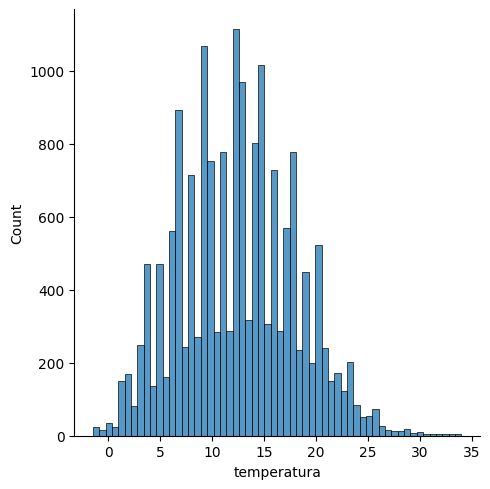

In [857]:
sns.displot(df_limpo, x='temperatura')
plt.show()

# O histograma mostra a distribuição dos intervalos no eixo X, em que a temperatura vai de 0 a 5, de 5 a 10, e assim por diante, podendo chegar ao máximo de 35. No eixo Y, temos a frequência, isto é, quantas vezes determinada faixa de temperatura aconteceu.
# Porém, note que temos várias barras com tamanhos maiores e menores ao longo do gráfico. 
# Podemos trabalhar melhor essas barras. Para isso, utilizaremos o parâmetro bins, responsável por definir a quantidade de barras que separam as informações. 

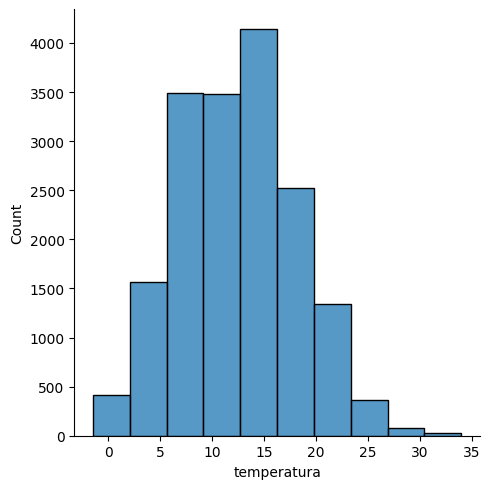

In [858]:
# Gerando o histograma de temperatura
sns.displot(df_limpo, x='temperatura', bins=10) #10 barras
plt.show()

# Analise da temperatura:
# temos menos informações quando são temperaturas muito baixas, como a barra da marcação de 0 graus, por exemplo. 
# Na sequência, temos a barra de 5 graus, que vai até a contagem de 1500, aproximadamente. 
# Depois temos as barras mais altas nas temperaturas intermediárias, mais amenas.

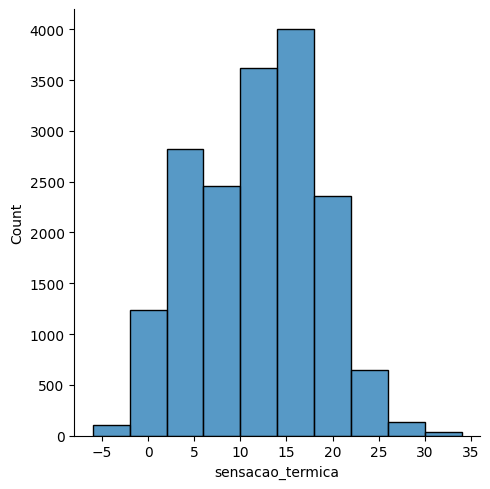

In [859]:
# Gerando o histograma da Sensacao Termica
sns.displot(df_limpo, x='sensacao_termica', bins=10)
plt.show()

# Analise da Sensaçao Termica:
# Temos um resultado semelhante ao gráfico anterior, com o mesmo caso de sensações térmicas muito baixas e muito altas com menor frequência, 
# concentrando as maiores barras na parte central do histograma, entre 10 e 15 de sensação térmica. 
# Com isto conseguimos verificar que isso está próximo do que seria uma distribuição normal, com a maioria dos valores no centro, enquanto os valores mais baixos e mais altos estão nas extremidades.

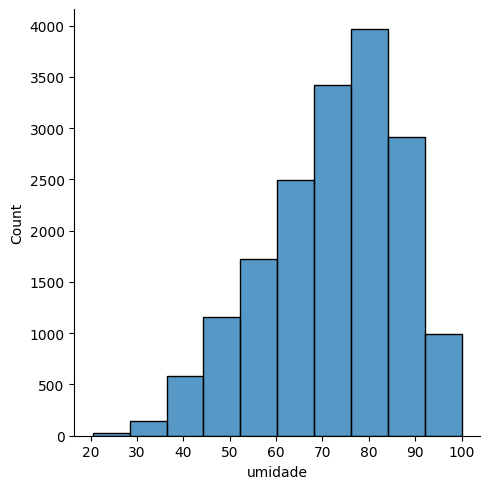

In [860]:
# Gerando o histograma da Umidade
sns.displot(df_limpo, x='umidade', bins=10)
plt.show()


# Analise da Umidade:
# Nesse caso, temos um padrão completamente diferente, distante da distribuição normal. Agora temos uma distribuição distorcida para a direita.
# Quando temos a umidade muito baixa, a frequência é bem pequena, e ela aumenta até chegar nas umidades mais recorrentes, de 70% e 80%. No final, a umidade volta a cair quando chega em 90% e 100%.
# É mais comum termos umidades mais ou menos altas do que umidades extremamente altas, como 100%, que seriam dias completamente úmidos e chuvosos, assim como umidades muito baixas, em dias muito secos.

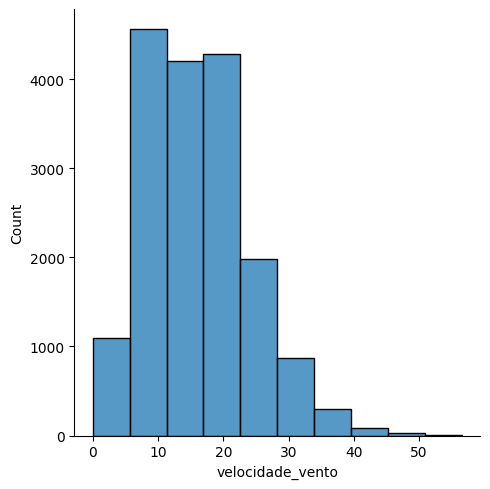

In [861]:
# Gerando o histograma da Velocidade do Vento
sns.displot(df_limpo, x='velocidade_vento', bins=10)
plt.show()

# Analise da Velocidade do Vento:
# temos um padrão completamente diferente. O histograma anterior estava distorcido para a direita, e agora temos outro tipo de distorção, chamado em estatística de distorção para a esquerda.
# Quando a velocidade do vento está muito baixa, também temos pouca frequência, o que faz sentido, pois deve ser um dia muito quente.
# Já quando a velocidade do vento está muito alta, acima de 20 quilômetros por hora, aproximadamente, até chegar em 50 quilômetros por hora, a frequência é muito menor. 
# Por fim, nas velocidades entre 10 e 20 quilômetros por hora, temos as maiores frequências.

# Explorando os dados Categoricos

In [862]:
# Obtendo estatísticas descritivas
df_limpo.describe(include=[object])  # include=[object] parâmetro específico para focar somente nas categorias

,data_hora,clima,feriado,fim_de_semana,estacao
count,17414,17414,17414,17414,17414
unique,17414,6,2,2,4
top,2015-01-04 00:00:00,Céu limpo,Não,Não,Primavera
freq,1,6150,17030,12444,4394


In [863]:
# O resumo inclui a contagem de entradas (count)
# os valores únicos de cada coluna (unique), exibindo quantas categorias temos
# a categoria mais frequente (top, equivalente à moda) 
# e a frequência dessa categoria (freq), indicando quantas vezes ela apareceu nos dados.

In [864]:
# Observamos que na variável "clima" encontramos seis valores únicos, sendo "céu limpo" o mais comum, ocorrendo 6.150 vezes. 
# Na variável "feriado", há apenas duas categorias, sendo "não" a mais frequente com 17.030 ocorrências, o que é compreensível considerando a escassez de feriados ao longo do ano.
# Quanto à variável "fim de semana", também há dois valores únicos, sendo "não" o mais frequente com 12.444 registros. 
# Por fim, na variável "estação", identificamos quatro valores únicos, sendo "primavera" a estação mais comum, ocorrendo 4.394 vezes.

In [865]:
# Como anteriormente temos apenas o número de categorias, como os seis tipos de clima, mas não sabemos quais são esses valores específicos. 
# Foi criando uma lista que contenha os nomes das colunas relevantes, como clima, feriado, fim_de_semana e estação. E na sequencia imprimir os valores únicos associados a cada coluna. 
['clima', 'feriado', 'fim_de_semana', 'estacao']

['clima', 'feriado', 'fim_de_semana', 'estacao']

In [866]:
for col in ['clima', 'feriado', 'fim_de_semana', 'estacao']:
    print(f'Coluna: {col}')
    print(df_limpo[col].unique())
    print('='*15,'\n')

Coluna: clima
['Nublado' 'Céu limpo' 'Parcialmente nublado' 'Chuva leve' 'Neve'
 'Chuva com trovoadas']

Coluna: feriado
['Não' 'Sim']

Coluna: fim_de_semana
['Sim' 'Não']

Coluna: estacao
['Inverno' 'Primavera' 'Verão' 'Outono']



In [867]:
# Em relação às colunas, temos algumas informações interessantes:
# Na coluna clima, encontramos diferentes condições como clima "nublado", "céu limpo", "parcialmente nublado", "chuva leve", "neve" e "chuva com trovoadas".
# A coluna feriado é binária, indicando apenas "sim" ou "não". O mesmo se aplica à coluna "final de semana", onde também temos "sim" e "não". 
# Por último, na coluna estação, encontramos as estações do ano: "inverno", "primavera", "verão" e "outono".

# Comparando dias normais, feriados e finais de semana

 investigar se a demanda por locações é maior ou menor durante os feriados. Para isso, utilizaremos um gráfico de distribuição, que nos permitirá comparar as respostas de sim ou não e visualizar características como a mediana.

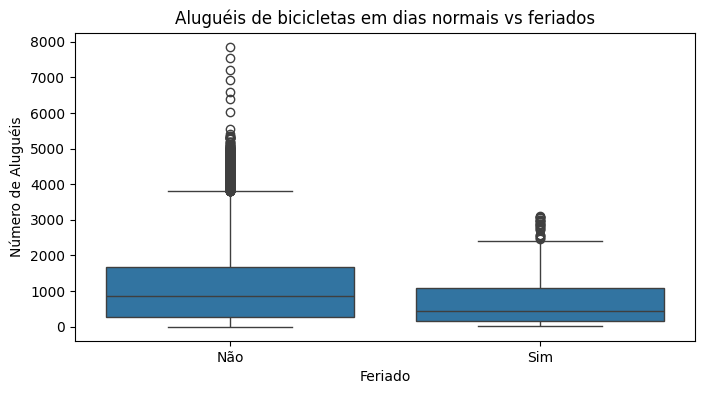

In [868]:
#Criando o Grafico de Distribuiçao para a analise
plt.figure(figsize=(8, 4))
sns.boxplot(x='feriado', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs feriados')
plt.xlabel('Feriado')
plt.ylabel('Número de Aluguéis')
plt.show()

Analisando nos finais de semana:

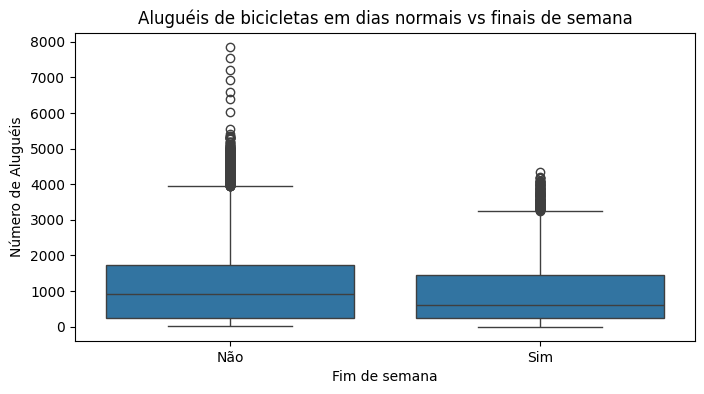

In [869]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='fim_de_semana', y='contagem', order=['Não', 'Sim'], data=df_limpo)
plt.title('Aluguéis de bicicletas em dias normais vs finais de semana')
plt.xlabel('Fim de semana')
plt.ylabel('Número de Aluguéis')
plt.show()

Calculando a mediana de bicicletas alugadas para cada condição em feriado e fim_de_semana:

In [870]:
# MEDIANA FERIADO

# Utilizaremos a função de agregação groupby() com o parâmetro feriado para agrupar os dados. 
# Em seguida, vamos extrair a contagem dos registros. 
# Posteriormente, definiremos a estatística que desejamos visualizar, que será a mediana, utilizando a função median().

mediana_feriado = df_limpo.groupby('feriado')['contagem'].median()  

In [871]:
# MEDIANA FIM DE SEMANA
mediana_fim_de_semana = df_limpo.groupby('fim_de_semana')['contagem'].median()

In [872]:
# Observamos que ao executarmos a célula a mediana de bicicletas alugadas em dias não feriados é de 855. 
# No entanto, nos dias considerados feriados, esse número cai significativamente para 439. Este é um insight importante que podemos extrair desses dados
mediana_feriado

feriado
Não    855.0
Sim    439.5
Name: contagem, dtype: float64

In [873]:
# Nos dias úteis (não finais de semana), a mediana é de 927, enquanto nos fins de semana, a mediana diminui para 619. 
# Esses números nos fornecem uma visão clara das diferenças no aluguel de bicicletas ao longo da semana.
mediana_fim_de_semana

fim_de_semana
Não    927.0
Sim    619.0
Name: contagem, dtype: float64

Investigando como o clima afeta a demanda:

criar um gráfico que representa a distribuição dos aluguéis conforme cada tipo de clima. 
Esses tipos podem incluir condições como nublado, céu limpo e parcialmente nublado, entre outros. A visualização gráfica nos permitirá compreender de maneira mais clara e interessante a relação entre clima e aluguéis de bicicletas.

In [874]:
# Agurpando pela coluna 'clima' com a funçao groupby(). e fazendo a contagem com a funçao .sum()
df_clima = df_limpo.groupby('clima')['contagem'].sum()
df_clima

clima
Chuva com trovoadas        8168
Chuva leve              1526461
Céu limpo               7146847
Neve                      15051
Nublado                 4243887
Parcialmente nublado    6965558
Name: contagem, dtype: int64

In [875]:
#  transformado em um dataframe com index
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index()
df_clima

,clima,contagem
0,Chuva com trovoadas,8168
1,Chuva leve,1526461
2,Céu limpo,7146847
3,Neve,15051
4,Nublado,4243887
5,Parcialmente nublado,6965558


Ordenando do maior para o menor valor

In [876]:
# Vamos ordenar esses valores. 
# Para aparecer do clima que tem maior quantidade até o que tem menos, vamos colocar um .sort_values() após o reset_index(). Essa função ordena os valores.
# inserimos um by dentro dos parênteses, para informar por qual coluna desejamos que isso seja ordenado. No caso, desejamos pela contagem. Então, vai ser o by = 'contagem'. 
# Na sequência, inserimos uma vírgula e colocamos qual é o sentido da ordenação.
# Se é do menor para o maior ou do maior para o menor, que é o que queremos de fato. Então, para ser nessa ordem, vamos colocar um parâmetro chamado ascending = False.

df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(by='contagem', ascending=False)
df_clima

,clima,contagem
2,Céu limpo,7146847
5,Parcialmente nublado,6965558
4,Nublado,4243887
1,Chuva leve,1526461
3,Neve,15051
0,Chuva com trovoadas,8168


# Criando o gráfico de barras com Seaborn

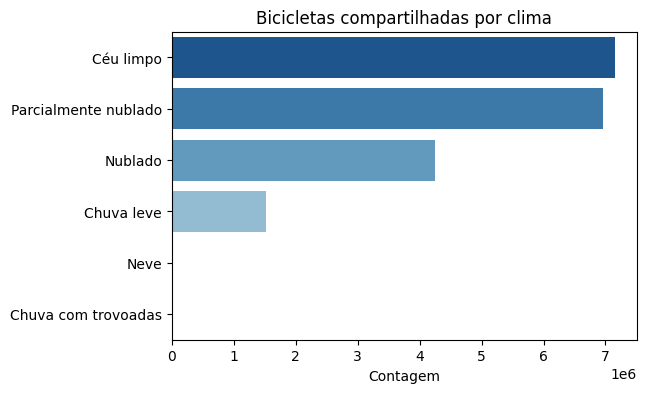

In [877]:
df_clima = df_limpo.groupby('clima')['contagem'].sum().reset_index().sort_values(by='contagem', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=df_clima, y='clima', x='contagem', hue='clima', palette='Blues_r', orient='h')
plt.title('Bicicletas compartilhadas por clima')
plt.xlabel('Contagem')
plt.ylabel('')
plt.show()

 O gráfico mostra que, com o céu limpo, a maior quantidade de bicicletas é alugada. Estamos apresentando os números de contagem de 0 a 1, 2, 3 e assim por diante, porém eles estão elevados à sexta potência. Portanto, os valores são bem altos, mas o gráfico mostra apenas o primeiro número e sua potência correspondente.

Quando o céu está limpo, observamos um aumento significativo no número de pessoas que alugam bicicletas, possivelmente porque estão indo trabalhar ou realizando suas atividades diárias. Surpreendentemente, quando o céu está parcialmente nublado, a quantidade de aluguéis é semelhante à registrada em dias de céu completamente limpo.

No entanto, quando o céu está totalmente nublado, observamos uma queda considerável nas locações de bicicletas. Essa queda se intensifica ainda mais em dias de chuva leve.

Parece que as pessoas tendem a evitar o uso de bicicletas em dias de chuva leve. E em condições climáticas mais adversas, como neve ou chuva com trovoadas, a quantidade de aluguéis é tão baixa que mal aparece nos registros.

In [878]:
df_clima

,clima,contagem
2,Céu limpo,7146847
5,Parcialmente nublado,6965558
4,Nublado,4243887
1,Chuva leve,1526461
3,Neve,15051
0,Chuva com trovoadas,8168


Ao analisarmos os dados, notamos que em dias de neve, o número de aluguéis de bicicletas é de apenas 15.051. 

 Apesar de ser um número considerável, dado o desafio adicional de andar de bicicleta em condições de neve, podemos dizer que existe uma pequena demanda durante esse período.

Da mesma forma, em dias de chuva com trovoadas, também há registros de aluguéis, totalizando 8.168. Mesmo em condições climáticas desfavoráveis, como neve ou trovoadas, ainda há uma demanda por aluguéis de bicicletas. No entanto, é importante destacar que a maioria dos aluguéis está associada a dias de céu limpo e parcialmente nublado.

# Analisando as distribuições por estação

In [879]:
# Observando o gráfico, podemos notar algumas tendências:
# No verão, a caixa do boxplot é a mais larga, a mediana é mais elevada em comparação com outras estações, e a amplitude também é maior. 
# Já no inverno, a distribuição é mais compacta, com uma mediana relativamente baixa. No entanto, há vários outliers.
# A primavera apresenta uma contagem de aluguéis mais alta, com uma mediana superior à do inverno. 
# O outono e a primavera mostram semelhanças, com medianas mais altas que as do inverno e caixas de tamanho similar.


# Observamos que a primavera e o outono são bastante semelhantes, enquanto as outras apresentam diferenças significativas. 
# O inverno se destaca como muito diferente, enquanto o verão se destaca pelo alto volume de demanda. 
# Podemos comparar as medianas para entender melhor essas diferenças.


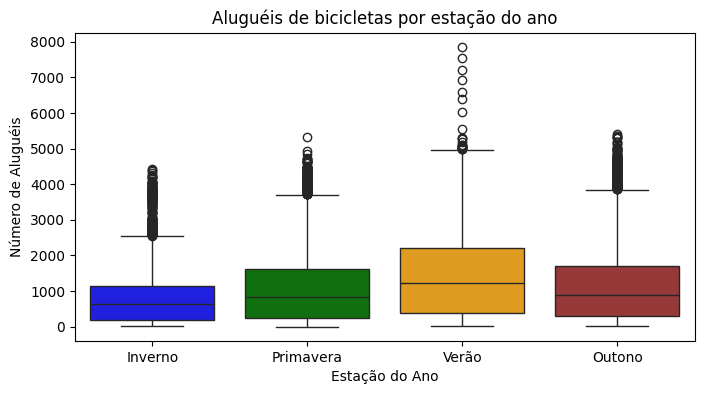

In [880]:
plt.figure(figsize=(8, 4))
paleta_cores = {'Primavera': 'green', 'Verão': 'orange', 'Outono': 'brown', 'Inverno': 'blue'}
sns.boxplot(x='estacao', y='contagem', data=df_limpo, hue='estacao', palette=paleta_cores)
plt.title('Aluguéis de bicicletas por estação do ano')
plt.xlabel('Estação do Ano')
plt.ylabel('Número de Aluguéis')
plt.show()

In [881]:
 
# Comparando a mediana de cada estaçao obtemos os seguintes resultados: 
# no inverno, a mediana de bicicletas alugadas é de 632; 
# no outono, 898; na primavera, 823; 
# e no verão, a mediana mais alta é de 1.214 bicicletas alugadas. 
# Esses números evidenciam as variações na demanda ao longo das estações do ano.

df_limpo.groupby('estacao')['contagem'].median()

estacao
Inverno       632.0
Outono        898.0
Primavera     823.0
Verão        1214.0
Name: contagem, dtype: float64

Teste Mann-Whitney

Vamos aplicar um teste chamado Mann-Whitney, que é um teste não paramétrico para amostras que são independentes, para descobrir se as distribuições entre outono e primavera são iguais ou são diferentes.

A nossa hipótese nula é que a distribuição nas duas estações são iguais, e a nossa hipótese alternativa é que as distribuições são diferentes. Para usar esse teste, vamos ter que importá-lo da biblioteca chamada SciPy, que é utilizada para testes estatísticos. Vamos importar o MannWhitneyU e filtrar os nossos dados para outono e primavera para comparar.


In [882]:
from scipy.stats import mannwhitneyu

primavera = df_limpo[df_limpo['estacao'] == 'Primavera']['contagem']
outono = df_limpo[df_limpo['estacao'] == 'Outono']['contagem']

u_statistic, p_value = mannwhitneyu(primavera, outono, alternative='two-sided')
u_statistic, p_value

(np.float64(9044682.5), np.float64(0.0004762100221646297))

Nosso p_value é 0.00047, que é um valor menor que 0.05. Quando o p é menor que 0.05, descartamos a hipótese nula e ficamos com a nossa hipótese alternativa. Ou seja, as distribuições são, sim, diferentes. 
A ideia, então, é que essa empresa tenha planos de ações diferentes para cada uma das estações.

# ANALISANDO OS DADOS AO LONGO DO TEMPO

In [883]:
#Convertendo o tipo do dado "data e hora"
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17414 non-null  object 
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  object 
 7   feriado           17414 non-null  object 
 8   fim_de_semana     17414 non-null  object 
 9   estacao           17414 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 1.5+ MB


In [884]:
# A coluna data_hora é do tipo objeto (object). Se queremos trabalhar com algo ao longo do tempo, 
# precisamos aplicar um tratamento nessa coluna, porque seus dados precisam ser de um tipo chamado datetime para que possamos trabalhar com o tempo de maneira correta.

In [885]:
#  cópia do nosso DataFrame, para não perdê-lo sobrescrevendo dados nele
df_data = df_limpo.copy()

In [886]:
# Convertendo a coluna data_hora para o formato datetime:

df_data['data_hora'] = pd.to_datetime(df_data['data_hora'])

df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno


In [887]:
# nosso novo DataFrame, notaremos que o tipo da coluna data_hora mudou para datetime64[ns], o tipo que queremos trabalhar.
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data_hora         17414 non-null  datetime64[ns]
 1   contagem          17414 non-null  int64         
 2   temperatura       17414 non-null  float64       
 3   sensacao_termica  17414 non-null  float64       
 4   umidade           17414 non-null  float64       
 5   velocidade_vento  17414 non-null  float64       
 6   clima             17414 non-null  object        
 7   feriado           17414 non-null  object        
 8   fim_de_semana     17414 non-null  object        
 9   estacao           17414 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 1.5+ MB


Extraindo mês e hora para colunas separadas

In [888]:
# Criando novas colunas: mes e horario

df_data['mes'] = df_data['data_hora'].dt.month # month traz somente o mes
df_data['horario'] = df_data['data_hora'].dt.hour # hour traz somente o horario

In [889]:
df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [890]:
# Retirando o horário da coluna data_hora

df_data['data_hora'] = df_data['data_hora'].dt.date

df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


Renomeando a coluna data_hora

In [891]:
# Renomeando a coluna data_hora para data:

df_data = df_data.rename(columns={'data_hora': 'data'})

df_data.head()

,data,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,horario
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [892]:
#A coluna data realmente voltou a ser de tipo objeto:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data              17414 non-null  object 
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  object 
 7   feriado           17414 non-null  object 
 8   fim_de_semana     17414 non-null  object 
 9   estacao           17414 non-null  object 
 10  mes               17414 non-null  int32  
 11  horario           17414 non-null  int32  
dtypes: float64(4), int32(2), int64(1), object(5)
memory usage: 1.6+ MB


In [893]:
# Vamos fazer novamente a conversão para o datetime:

# Convertendo a coluna data para o formato datetime:

df_data['data'] = pd.to_datetime(df_data['data'])

In [894]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data              17414 non-null  datetime64[ns]
 1   contagem          17414 non-null  int64         
 2   temperatura       17414 non-null  float64       
 3   sensacao_termica  17414 non-null  float64       
 4   umidade           17414 non-null  float64       
 5   velocidade_vento  17414 non-null  float64       
 6   clima             17414 non-null  object        
 7   feriado           17414 non-null  object        
 8   fim_de_semana     17414 non-null  object        
 9   estacao           17414 non-null  object        
 10  mes               17414 non-null  int32         
 11  horario           17414 non-null  int32         
dtypes: datetime64[ns](1), float64(4), int32(2), int64(1), object(4)
memory usage: 1.6+ MB



# Analisando a demanda por horário

# Gráfico de Bicicletas alugadas por hora

In [895]:
#Criando o Dataframe e Agrupando por horário e somando a contagem de bicicletas
df_por_hora = df_data.groupby('horario')['contagem'].sum().reset_index()

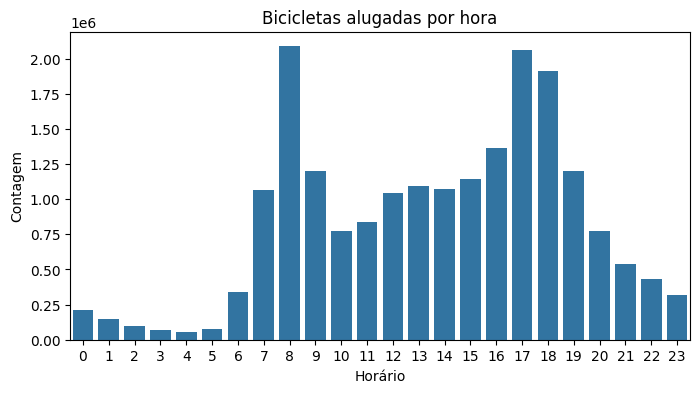

In [896]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_por_hora, x='horario', y='contagem')
plt.title('Bicicletas alugadas por hora')
plt.xlabel('Horário')
plt.ylabel('Contagem')

plt.show()

# Gráfico de Bicicletas alugadas por hora no fim de semana

In [897]:
# Criando o dataframe filtrando somente o valores pelo fim de semana
# Agrupando por horário e somando a contagem de bicicletas somente do fim de semana
df_fim_de_semana = df_data[df_data['fim_de_semana'] == 'Sim']
alugueis_fim_de_semana = df_fim_de_semana.groupby('horario')['contagem'].sum().reset_index()

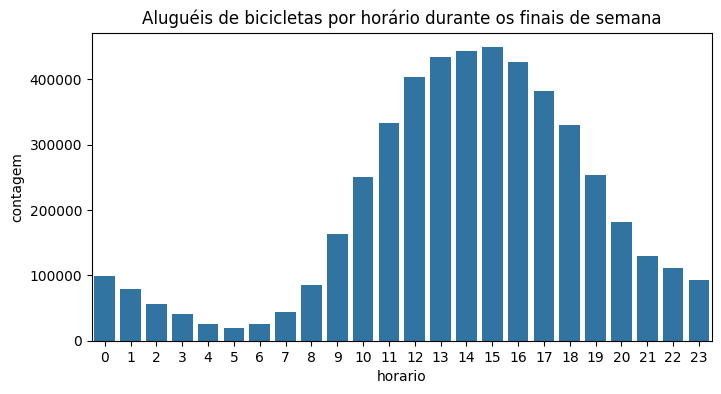

In [898]:
plt.figure(figsize=(8,4))
sns.barplot(x='horario', y='contagem', data=alugueis_fim_de_semana)
plt.title('Aluguéis de bicicletas por horário durante os finais de semana')
plt.show()

Analisando o gráfico, podemos observar que o padrão é completamente diferente do de dias de semana. Nos finais de semana, os picos de aluguel de bicicletas ocorrem entre o meio-dia e final da tarde, atingindo o maior pico às 15 horas, provavelmente quando as pessoas estão usando as bicicletas para lazer!

Analisando os horários, entendemos que a demanda por bicicletas varia conforme o dia da semana e o comportamento das pessoas ao longo do dia: de segunda à sexta, as pessoas as usam mais para deslocamentos cotidianos, como trabalho e estudos; nos fins de semana, usam para passeio.

# Analisando a demanda por dia e mês


# Gráfico de linhas: Bicicletas alugadas por dia

In [899]:
# Criando o dataframe e agrupando os dados pela data, somando a contagem de bicicletas para cada uma das datas 
df_tempo = df_data.groupby('data')['contagem'].sum().reset_index()

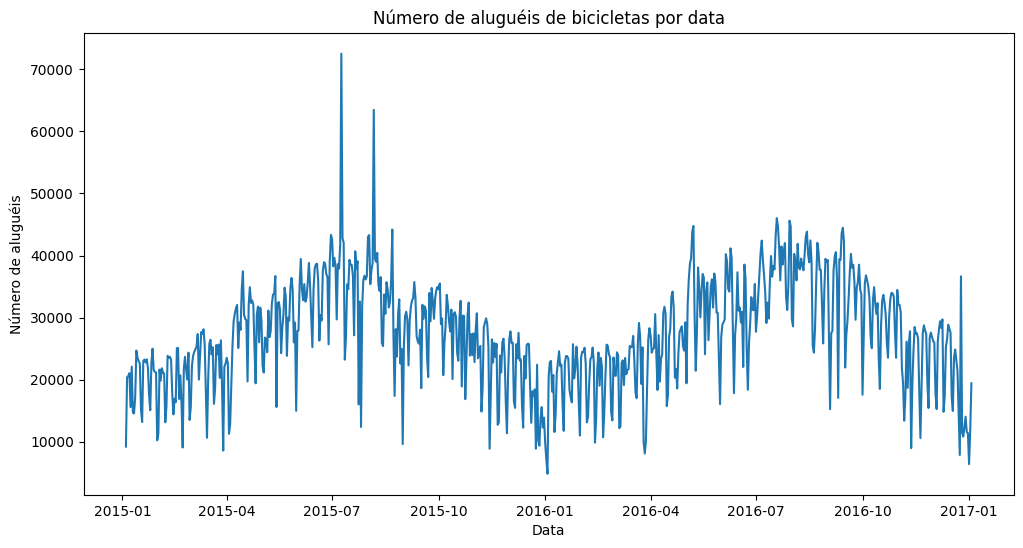

In [900]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_tempo, x='data', y='contagem')
plt.title('Número de aluguéis de bicicletas por data')
plt.xlabel('Data')
plt.ylabel('Número de aluguéis')
plt.show()

Se observarmos bem, no começo de 2015, a contagem parece ser mais baixa, e vai aumentando gradativamente até o meio do ano, entre junho e julho, e depois disso volta a cair até o final do ano. Esse padrão se repete para o ano seguinte, de 2016.

Mas há alguns detalhes curiosos. O ano de 2015 tem dois picos enormes entre julho e agosto, significativamente mais altos que todo o resto do gráfico. O que será que aconteceu em Londres nesse dia para esse pico ser tão grande?

Conforme nossas pesquisas, houve uma greve no metrô de Londres em julho e agosto de 2015. Na falta de transporte público para se locomover para o trabalho ou para estudar, as pessoas alugaram bicicletas. Por isso o número de aluguéis se elevou tanto nesse período!

# Gráfico de barras: bicicletas alugadas por mês

In [901]:
# Criando novo dataframe onde ele vai receber o df_data agrupado agora pelo mês e Vamos também somar a contagem de bicicletas
alugueis_mensais = df_data.groupby('mes')['contagem'].sum().reset_index()

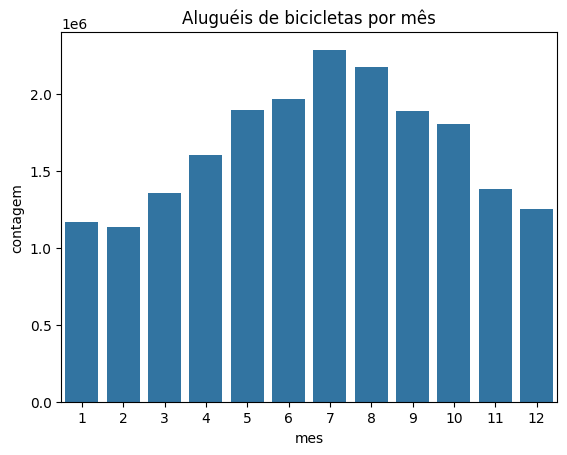

In [902]:
sns.barplot(data=alugueis_mensais, x='mes', y='contagem')
plt.title('Aluguéis de bicicletas por mês')
plt.show()

Temos os meses no eixo x, a contagem no eixo y (na escala de milhões, com valores elevados à sexta potência).

Observando o gráfico, concluímos que os meses de janeiro e fevereiro têm os números de aluguel mais baixos. Eles vão aumentando ao longo do ano, subindo gradativamente até chegar em julho, o mês com o maior número de bicicletas alugadas. Também temos alta quantidade de bicicletas alugadas em agosto. A partir de setembro, esse número cai gradativamente até dezembro.

Isso é exatamente o que intuímos no gráfico de linhas: há um padrão que se repete de um ano para o outro. Esse tipo de padrão se chama sazonalidade!

Isso pode estar ligado, por exemplo, às estações do ano. Quando analisamos os dados pelas estações, concluímos que o verão era a estação com a maior quantidade de bicicletas alugadas, o que se confere com o gráfico que plotamos agora. Na Europa, o verão é no meio do ano, ao contrário do Brasil.

# CONSTRUINDO O MODELO PREDITIVO:

In [903]:
from prophet import Prophet

In [904]:
# Criando o dataframe e renomeando o nome das colunas pois o Prophet reconhece a data como ds e a contagem como y
df_prophet = df_data[['data', 'contagem']].rename(columns={'data': 'ds', 'contagem': 'y'})
df_prophet.head()

,ds,y
0,2015-01-04,182
1,2015-01-04,138
2,2015-01-04,134
3,2015-01-04,72
4,2015-01-04,47


In [905]:
# Agrupamento de dados
# Como foi removido os horários das datas, temos dias repetidos no nosso dataframe. 
# Precisamos agrupar essas informações para termos apenas um registro por dia, com a soma das contagens para aquele dia.
# Funcionou conforme esperávamos e temos cerca de 730 dias para prever o futuro.
df_prophet = df_prophet.groupby('ds')['y'].sum().reset_index()
df_prophet

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


Definindo a semente aleatória

In [906]:
# Definindo um seed para garantir a reprodutibilidade dos resultados
import numpy as np
np.random.seed(4587)

# Criação e treinamento do modelo utilizando Prophet

In [907]:
# Instanciando o modelo Prophet
modelo = Prophet() # variável  modelo

# Treinando o modelo - fit faz que o Modelo conheça os dados
modelo.fit(df_prophet)

18:07:24 - cmdstanpy - INFO - Chain [1] start processing
18:07:25 - cmdstanpy - INFO - Chain [1] done processing


In [908]:
# Criando um dataframe para previsões futuras com datas do futuro, onde o modelo ira conseguir predizer quais serao os valores depois desse Y novo que vai ser predito
# Utilizaremos a função .make_future_dataframe() do Prophet para gerar essas datas, especificando o período desejado, que será 90 dias, e a frequência, que definiremos como D em referência aos dias.
futuro = modelo.make_future_dataframe(periods=90, freq='D')  #Freq = D - Em Dias

In [909]:
#Realizando a previsão
previsao = modelo.predict(futuro)

# Explorando os resultados da previsão

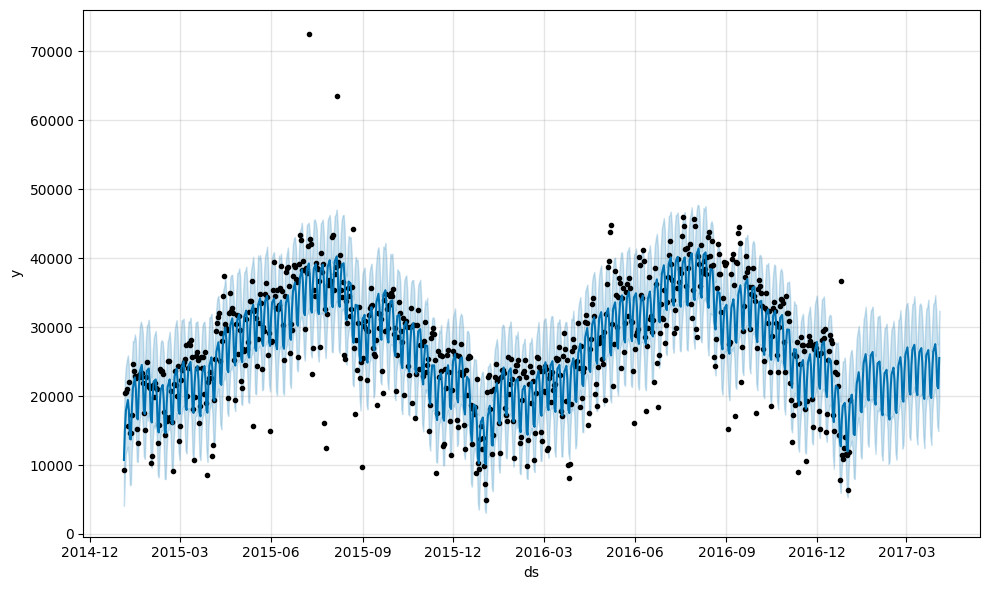

In [910]:
#Visualização dos resultados da previsao 
# Interpretação do gráfico de séries temporais
fig1 = modelo.plot(previsao)

À primeira vista, o gráfico pode parecer um pouco confuso, mas vamos entendê-lo juntos. Lembra do gráfico de linhas que criamos na aula anterior, representando as datas e a contagem de bicicletas? Aqui, temos algo semelhante. No eixo x, temos as datas, e no eixo y, a contagem de bicicletas.

A linha azul escura que percorre todo o período representa nossa previsão, os valores que o Prophet está prevendo. No gráfico, também vemos vários pontos pretos ao longo da linha. Esses pontos pretos são nossos valores reais de y, os valores que tínhamos no dataframe para cada dia.

Além disso, há uma faixa azul mais clara envolvendo a linha de previsão. Essa faixa é o nosso intervalo de confiança. É importante que os pontos pretos, nossos valores reais de y, estejam dentro desse intervalo de confiança.

Alguns pontos estão fora desse intervalo, e podemos visualizar isso. Esses pontos altos, que já tínhamos visto na aula anterior, são valores muito discrepantes que não foram previstos pelo modelo, pois são extremos.

Mas aqui está a questão: há um período, começando em 2017, em que não temos nenhum ponto preto. Por quê? Porque definimos um período de 90 dias para a previsão. Assim, os valores após essa linha azul são novos valores previstos pelo modelo com base nos dados anteriores.

In [911]:
# Explorando os valores previstos
previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2015-01-04,10731.194472,4082.926127,17013.553330
1,2015-01-05,15151.482034,8734.122925,22499.059827
2,2015-01-06,17864.565101,11661.391013,24283.835334
3,2015-01-07,18604.053644,12184.066799,25244.307222
4,2015-01-08,19425.165666,12658.315039,25912.237913
...,...,...,...,...
815,2017-03-30,27520.646802,21080.750776,34638.843848
816,2017-03-31,25747.493534,19545.347831,32277.834443
817,2017-04-01,21429.044453,15639.758041,27940.145665
818,2017-04-02,21116.561828,14941.201841,27457.190779


In [912]:
# No DataFrame, temos a coluna 'ds', que representa as datas, incluindo as datas futuras. 
# Temos também 'yhat', que é o valor calculado pelo modelo como a contagem de bicicletas para cada dia. 
# Além disso, temos 'yhat_lower', que é o limite inferior do intervalo de confiança, e 'yhat_upper', que é o limite superior do intervalo de confiança. 
# Esses valores nos ajudam a construir o gráfico e entender como a previsão está sendo feita.

Interpretação dos gráficos de componentes diferentes

 O Prophet é um modelo de regressão aditivo que adiciona diferentes componentes para fazer a previsão final.

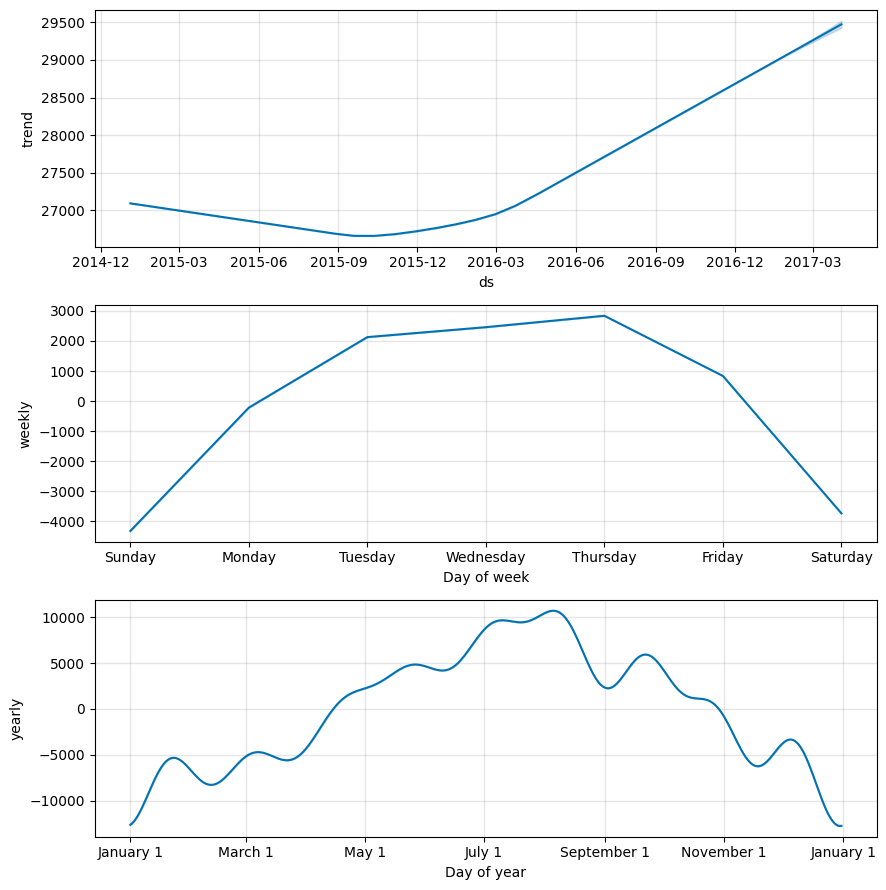

In [913]:
# Visualizando os componentes 
fig2 = modelo.plot_components(previsao)

In [914]:
# Ao executar, veremos três gráficos em uma mesma imagem. Cada gráfico representa um componente diferente que o Prophet utilizou para fazer a previsão.
# O primeiro componente é a tendência. Ele indica se a previsão está aumentando ou diminuindo. Aqui, indica que a previsão está subindo.
# Também temos dois componentes relacionados à sazonalidade, como discutimos na aula anterior. Um desses componentes é semanal, e podemos observar como os aluguéis diminuem nos finais de semana. 
# O gráfico mostra os valores para cada dia da semana, onde vemos que os aluguéis são mais baixos aos domingos, aumentam na segunda e terça-feira, 
# permanecem estáveis entre quarta e quinta-feira, e diminuem novamente de quinta para sexta-feira e de sexta para sábado.
# Outro componente considerado para a previsão é o anual. Podemos ver que os aluguéis são mais baixos em janeiro, # aumentam gradualmente até o meio do ano, alcançando o pico, e então diminuem novamente até o final do ano.

# Separando os dados em treino e teste

In [915]:
df_prophet.shape

(730, 2)

Criação dos DataFrames de treino e teste

In [916]:
# DataFrame de treino
df_treino = pd.DataFrame()

# Separando 80% dos dados para treino
df_treino['ds'] = df_prophet['ds'][:584] #
df_treino['y'] = df_prophet['y'][:584]

In [917]:
# DataFrame de teste
df_teste = pd.DataFrame()

# Separando 20% dos dados para teste
df_teste['ds'] = df_prophet['ds'][584:]
df_teste['y'] = df_prophet['y'][584:]

In [918]:
# Treinamento do modelo com dados de treino
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_treino)

18:07:27 - cmdstanpy - INFO - Chain [1] start processing
18:07:27 - cmdstanpy - INFO - Chain [1] done processing


Previsão dos dados futuros

In [919]:
# criando o dataframe do futuro e  fazendo a previsão do modelo:

np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods=150, freq='D') # definido um periodo de 150 dias
previsao = modelo.predict(futuro)

18:07:27 - cmdstanpy - INFO - Chain [1] start processing
18:07:27 - cmdstanpy - INFO - Chain [1] done processing


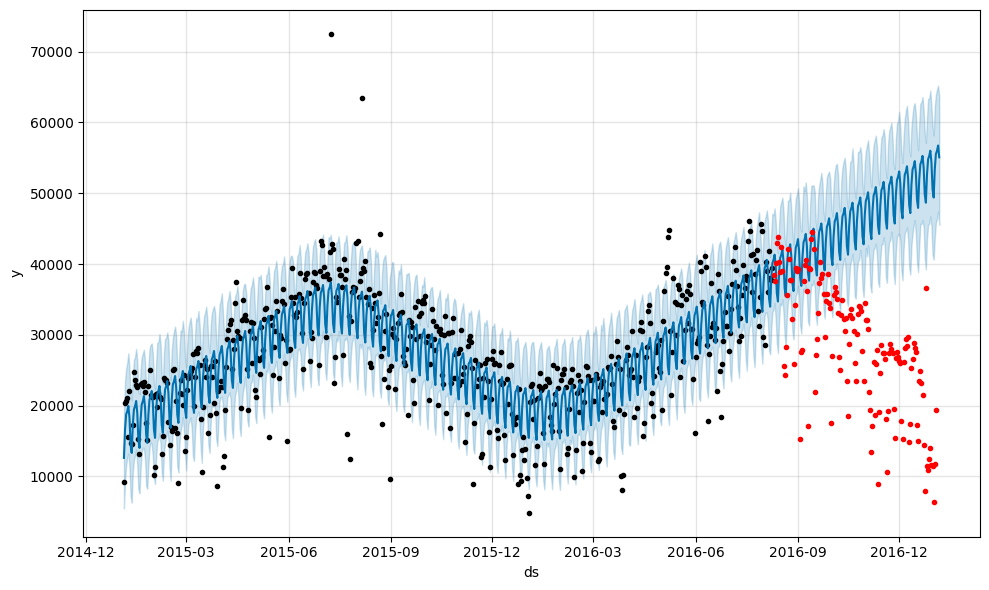

In [920]:
# Visualização da previsão e dos dados de teste
fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

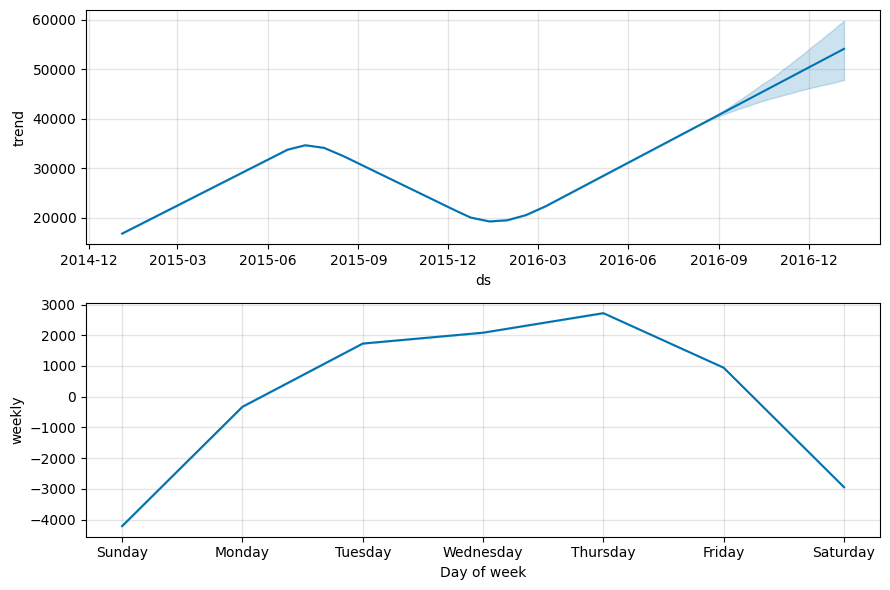

In [921]:
fig2 = modelo.plot_components(previsao)

Primeiro, vemos que a tendência está subindo, quando, na verdade, deveria estar descendo conforme os dados de teste indicam. Isso mostra que o modelo não conseguiu capturar corretamente a tendência dos dados.

Além disso, notamos que a sazonalidade anual não está sendo considerada, apenas a sazonalidade semanal. Isso ocorreu porque, quando rodamos o modelo, ele desabilitou a sazonalidade anual, conforme indicado na primeira linha da saída do modelo. Essa desativação da sazonalidade anual resultou em uma previsão inadequada.

# Obtendo métricas:

Métrica de avaliação da performance do modelo

Precisamos entender quão ruim está a performance do modelo. Para isso, utilizaremos uma métrica apropriada.

Quando trabalhamos com regressão linear, costumamos usar a métrica R² para avaliar a performance do modelo. Essa métrica é adequada para relações lineares.
No entanto, em séries temporais, não temos uma relação linear simples, já que os valores podem subir e descer devido a vários fatores, como sazonalidade. Portanto, a métrica R² não é a melhor escolha aqui.

A ideia é usar uma métrica adequada para séries temporais, que compare os valores previstos com os valores reais e forneça uma estimativa de quão precisas são as previsões. Queremos saber se estamos errando, em média, tantas bicicletas para cima ou para baixo.

In [928]:
# Criação de um DataFrame de comparação
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,40582.198661,38430
1,2016-08-11,41322.562633,37626
2,2016-08-12,39652.223660,40159
3,2016-08-13,35870.779908,43041
4,2016-08-14,34711.072047,43848
...,...,...,...
141,2016-12-30,54340.333474,11566
142,2016-12-31,50558.889721,11424
143,2017-01-01,49399.181860,6421
144,2017-01-02,53384.832734,11823


Observando os dados, notamos que, na primeira data do período de teste, 10 de agosto de 2016, o valor real de y foi 38.430 bicicletas, enquanto a previsão (yhat) foi de 40.646 bicicletas. A previsão foi relativamente próxima do valor real.

No entanto, para outras datas, especialmente mais para o final, os valores previstos estão bastante distantes dos valores reais. Por exemplo, em 30 de dezembro de 2016, o valor real foi de 11.500 bicicletas, mas a previsão foi de 54.505 bicicletas, uma diferença enorme.

# Cálculo do RMSE:


Quantificação dos erros
Fórmula do Erro Quadrático Médio (MSE)
Para quantificar esses erros, precisamos de uma métrica que compare os valores reais (y) com os valores previstos (yhat) e calcule uma média do erro. Uma métrica adequada para isso é o Erro Quadrático Médio (MSE), que nos dá uma noção clara de quanto o modelo está errando em média.

Fórmula do Erro Quadrático Médio (MSE) expressa como MSE igual a soma, de índice i, da diferença entre y subscrito i e y com um acento circunflexo subscrito i ao quadrado, tudo isso dividido por n.

Essa métrica pega a diferença entre os valores reais (y) e previstos (yhat), subtraindo-os. Em seguida, eleva essa diferença ao quadrado, soma todos esses valores e depois divide pelo número de observações (n), que é o número de linhas do nosso DataFrame (146). Isso penaliza erros maiores devido à elevação ao quadrado.

In [929]:
#Para obter um valor mais compreensível, tiramos a raiz quadrada do MSE, resultando na métrica Raiz do Erro Quadrático Médio (RMSE).
# Vamos calcular essas métricas usando a biblioteca SKLearn. Primeiro, importamos a função mean_squared_error.
# Vamos calcular o MSE. Primeiro, definiremos o mse como a função mean_squared_error() e passamos os valores de y e yhat do df_comparacao. 
# A função fará a subtração, elevará ao quadrado, somará os resultados e calculará a média.
# Com isso, obteremos o MSE. No entanto, como mencionado, precisamos calcular a raiz quadrada do MSE para obter o RMSE. 
# Para isso, definiremos rmse usando a função sqrt(), da biblioteca NumPy, passando o mse como parâmetro. 

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE:{mse}, RMSE:{rmse}')

MSE:461325709.7024581, RMSE:21478.494120921467


Note que o MSE resultou em um valor muito alto, como esperado, devido à elevação ao quadrado das diferenças. No entanto, o RMSE é mais compreensível e, neste caso, foi de 21.590. Isso significa que nosso modelo está errando, em média, 21.590 bicicletas por dia, o que é um erro bastante significativo.

# Melhorando as Previsoes:

Voltando na última previsão que obtivemos, vimos que todos os dados de teste estão fora da previsão. A previsão não entendeu que tínhamos essa sazonalidade anual e está indo para uma orientação que não queríamos que ela fosse, tornando o resultado confuso.

A ideia é tentar consertar isso e fazer uma previsão melhor para ter um resultado melhor.

In [933]:
# Ajustando a previsão
np.random.seed(4587)

modelo = Prophet(yearly_seasonality=True) # sazonalidade anual, definindo-a como verdadeira dentro do modelo, entre os parênteses de Prophet
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods=150, freq='D')
previsao = modelo.predict(futuro)

23:25:43 - cmdstanpy - INFO - Chain [1] start processing
23:25:43 - cmdstanpy - INFO - Chain [1] done processing


In [935]:
# Nesse código, temos a semente aleatória 4587. Começamos instanciando o modelo, depois fazemos o treinamento com os dados de treino, 
# temos o DataFrame do futuro sendo criado com os períodos e a frequência definida, além da previsão sendo feita no final.
# Como vimos anteriormente, ele acabou desabilitando a sazonalidade anual, porque não tinha entendido muito bem. 
# Tentaremos ativar essa questão nesse ponto, para ver se ele entende e a previsão melhora.

# Exibindo a previsão:

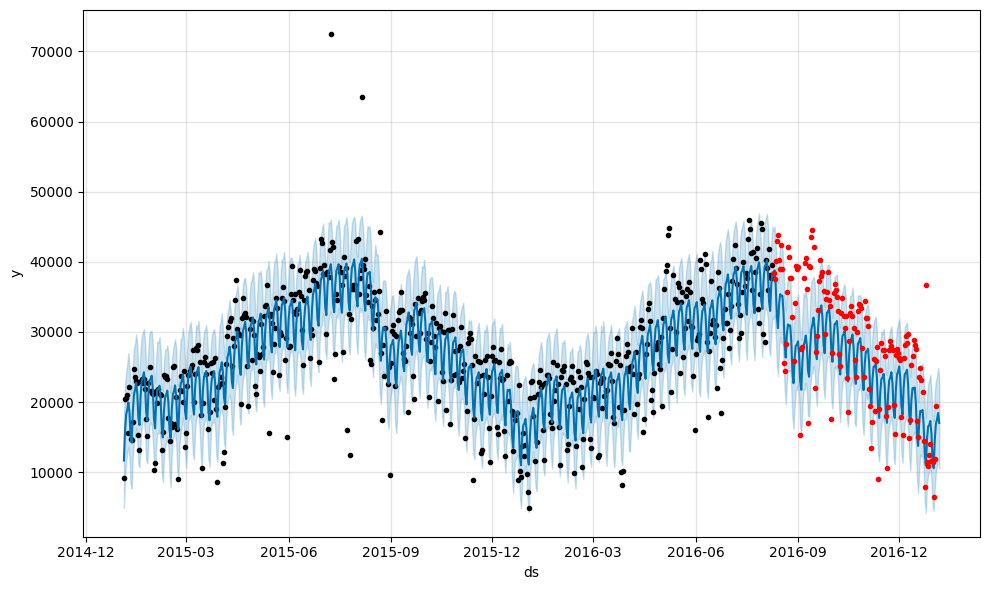

In [939]:
fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

O gráfico está bem melhor do que o anterior. Adicionando apenas um parâmetro e explicando para o Prophet sobre a sazonalidade anual, ele entendeu e conseguiu fazer a previsão corretamente.

No novo gráfico, temos os dados de teste mais encaixados dentro do intervalo de confiança. É óbvio que alguns dados ficaram pra fora, mas no geral temos uma previsão bem melhor.


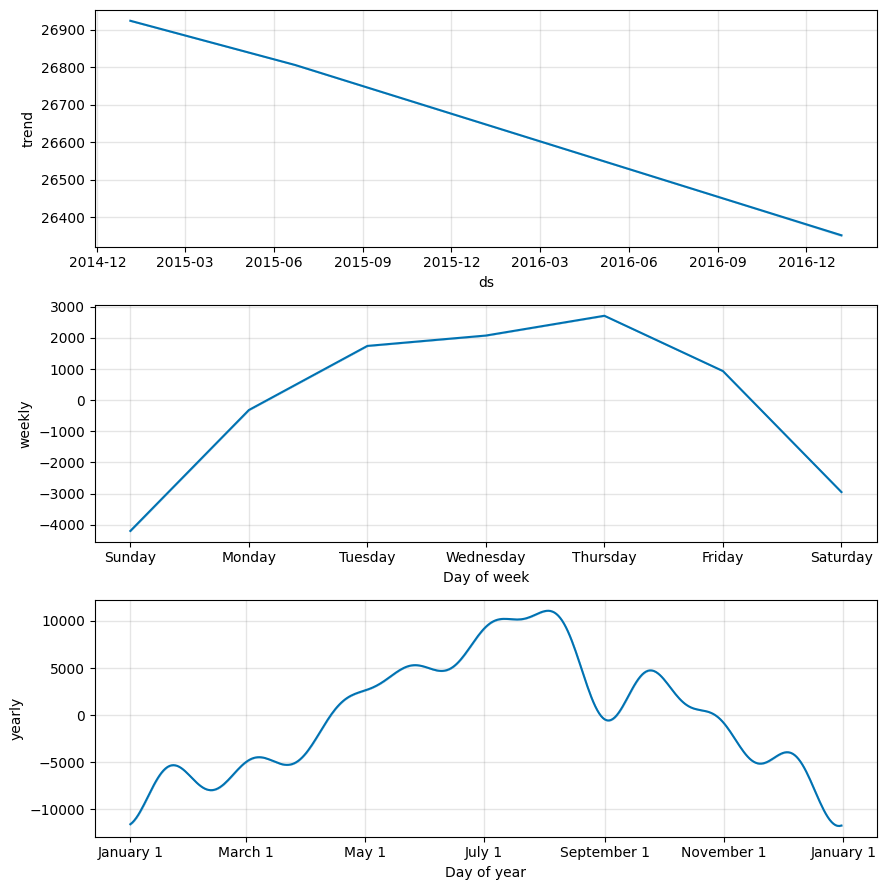

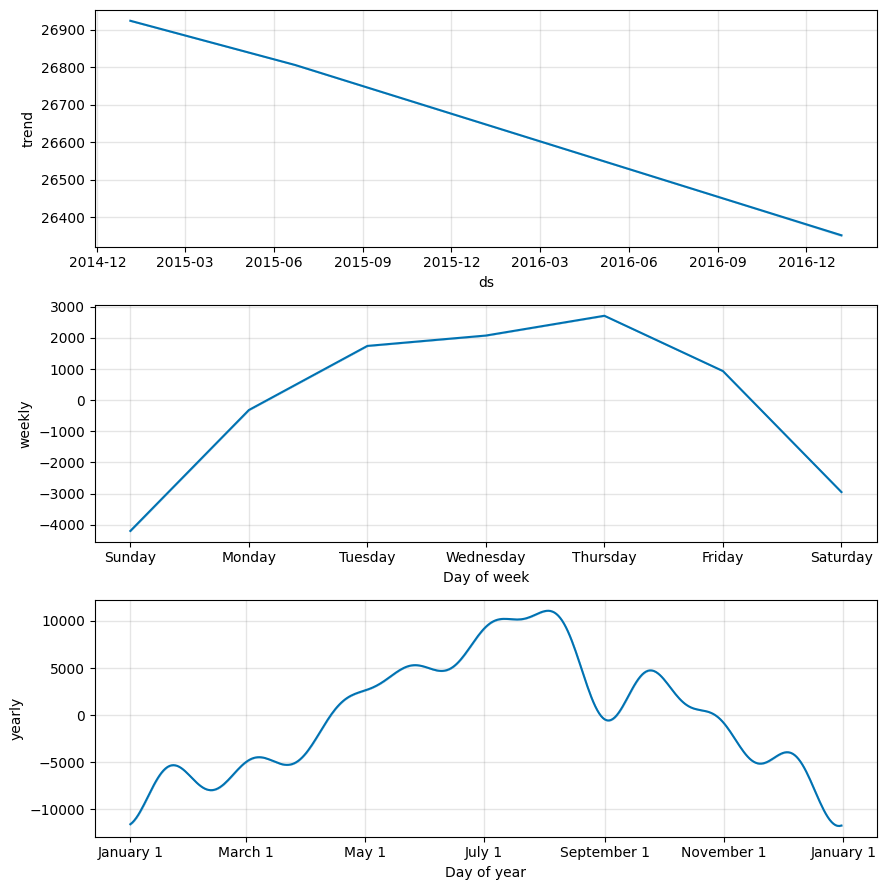

In [943]:
# Além disso, nos componentes que tínhamos antes, havia uma tendência subindo, quando deveria estar caindo. Vamos ver como isso ficou agora.
# Ao executar esse comando, temos três gráficos: "trend", "weekly" e "yearly", pois ativamos o anual, exibido por último.
# Neles, notaremos que a tendência está realmente descendo, porque estamos no período final do ano. Portanto, ele entendeu perfeitamente.
modelo.plot_components(previsao)

# Verificando o RMSE

In [946]:
#criando o DataFrame de novo, comparando o Y real com o yhat previsto do teste:
df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds') # O merge une os dois DataFrames e on='ds' cria essa união pela data.
df_comparacao

,ds,yhat,y
0,2016-08-10,38511.311807,38430
1,2016-08-11,38794.965012,37626
2,2016-08-12,36620.038853,40159
3,2016-08-13,32288.392385,43041
4,2016-08-14,30548.105832,43848
...,...,...,...
141,2016-12-30,15527.568155,11566
142,2016-12-31,11702.344894,11424
143,2017-01-01,10569.455731,6421
144,2017-01-02,14623.568132,11823


In [947]:
#Agora, quando chegamos no dia 30 de dezembro de 2016, o valor de Y real é de 11.566, enquanto Y previsto é de 15.473. São valores próximos.

In [950]:
# A partir disso, a ideia é calcular o RMSE e ver o que conseguimos.
# Vamos subir o código até a célula que faz o cálculo do MSE e do RMSE e copiar seu código, colando-o no final do notebook, na próxima célula vazia.
mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f'MSE:{mse}, RMSE:{rmse}')

MSE:38221787.96668081, RMSE:6182.377209996233


In [951]:
# Não falaremos sobre o MSE, porque é um valor muito alto. Mas o RMSE caiu de 21.000 bicicletas para 6.214, exibindo uma grande melhora. Estamos errando em aproximadamente 6.200 para cada dia que temos.

In [952]:
# Removendo os outliers
df_prophet

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [953]:
np.random.seed(4587)

modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods=0)
previsao = modelo.predict(futuro)

23:35:08 - cmdstanpy - INFO - Chain [1] start processing
23:35:08 - cmdstanpy - INFO - Chain [1] done processing


In [954]:
sem_outliers = df_prophet[(df_prophet['y'] > previsao['yhat_lower']) & (df_prophet['y'] < previsao['yhat_upper'])]

In [955]:
sem_outliers

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [956]:
# Criando o dataframe de treino
df_treino = pd.DataFrame()

df_treino['ds'] = sem_outliers['ds'][:505]
df_treino['y'] = sem_outliers['y'][:505]

In [957]:
# Criando o dataframe de teste
df_teste = pd.DataFrame()

df_teste['ds'] = sem_outliers['ds'][505:]
df_teste['y'] = sem_outliers['y'][505:]